# Notebook 03 — Exploratory Analysis of the S&P 500

This notebook performs exploratory analysis on the validated master S&P 500 dataset.

**Input**
- `data/raw/sp500_1950_present.csv`

**Objectives**
- Understand long-run price and volume behavior
- Examine OHLC relationships
- Analyze daily returns
- Examine volatility and drawdowns
- Compare historical eras
- Inspect distributions and outliers
- Generate reusable research figures and summary tables

This notebook is exploratory only. It does not train predictive models, alter the master dataset, or perform backtesting.


## 1. Imports

In [18]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Imports loaded successfully.")


Imports loaded successfully.


## 2. Configuration and Paths

The notebook is independently runnable and reloads the persisted master CSV from disk.


In [19]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data").exists():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data/quant-trading-research"),
    ]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            PROJECT_ROOT = candidate
            break

MASTER_PATH = PROJECT_ROOT / "data" / "raw" / "sp500_1950_present.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_DIR = PROJECT_ROOT / "reports" / "generated"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_COLUMNS = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj.Close",
    "Volume",
]

HISTORICAL_CUTOFF = pd.Timestamp("2018-07-12")

print(f"Master dataset: {MASTER_PATH}")


Master dataset: d:\quant-trading-research\data\raw\sp500_1950_present.csv


## 3. Load and Prepare the Validated Dataset

In [20]:
if not MASTER_PATH.exists():
    raise FileNotFoundError(
        f"Master dataset not found: {MASTER_PATH}. "
        "Run the corrected Notebook 01 first."
    )

df = pd.read_csv(MASTER_PATH, low_memory=False)

missing_columns = [c for c in EXPECTED_COLUMNS if c not in df.columns]
unexpected_columns = [c for c in df.columns if c not in EXPECTED_COLUMNS]

if missing_columns or unexpected_columns:
    raise ValueError(
        f"Unexpected dataset schema. Missing={missing_columns}, "
        f"Unexpected={unexpected_columns}"
    )

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

for column in EXPECTED_COLUMNS[1:]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = (
    df[EXPECTED_COLUMNS]
    .dropna(subset=["Date"])
    .sort_values("Date")
    .reset_index(drop=True)
)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
display(df.head())


Rows: 19,273


Date range: 1950-01-03 → 2026-08-11


,Date,Open,High,Low,Close,Adj.Close,Volume
0,1950-01-03,16.66,16.66,16.66,16.66,16.66,1260000
1,1950-01-04,16.85,16.85,16.85,16.85,16.85,1890000
2,1950-01-05,16.93,16.93,16.93,16.93,16.93,2550000
3,1950-01-06,16.98,16.98,16.98,16.98,16.98,2010000
4,1950-01-09,17.08,17.08,17.08,17.08,17.08,2520000


## 4. Create Research Features

These derived columns are created in memory only. The master CSV is not modified.

Features include:
- daily close return
- log return
- intraday return
- overnight return
- daily trading range
- range percentage
- rolling volatility
- rolling moving averages
- cumulative wealth index


In [21]:
df["daily_return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"]).diff()

df["intraday_return"] = (
    df["Close"] / df["Open"] - 1
)

df["overnight_return"] = (
    df["Open"] / df["Close"].shift(1) - 1
)

df["trading_range"] = df["High"] - df["Low"]
df["range_pct"] = df["trading_range"] / df["Close"]

df["volatility_21d"] = (
    df["daily_return"]
    .rolling(21)
    .std()
    * np.sqrt(252)
)

df["volatility_63d"] = (
    df["daily_return"]
    .rolling(63)
    .std()
    * np.sqrt(252)
)

df["sma_20"] = df["Close"].rolling(20).mean()
df["sma_50"] = df["Close"].rolling(50).mean()
df["sma_200"] = df["Close"].rolling(200).mean()

df["wealth_index"] = (
    (1 + df["daily_return"].fillna(0))
    .cumprod()
)

df["drawdown"] = (
    df["wealth_index"] /
    df["wealth_index"].cummax()
    - 1
)

print("Research features created.")
display(df.tail())


Research features created.


,Date,Open,High,Low,Close,Adj.Close,Volume,daily_return,log_return,intraday_return,overnight_return,trading_range,range_pct,volatility_21d,volatility_63d,sma_20,sma_50,sma_200,wealth_index,drawdown
19268,2026-08-05,7771.620117,7793.680176,7720.169922,7723.549805,7723.549805,5615640000,-0.001676,-0.001678,-0.006185,0.004537,73.510254,0.009518,0.142028,0.140244,7507.978467,7485.677813,7039.687402,463.598428,-0.001676
19269,2026-08-06,7713.790039,7742.850098,7698.149902,7709.959961,7709.959961,5330830000,-0.001760,-0.001761,-0.000497,-0.001264,44.700195,0.005798,0.141678,0.137603,7516.294458,7489.494609,7044.917153,462.782711,-0.003433
19270,2026-08-07,7735.180176,7763.080078,7719.189941,7757.640137,7757.640137,5019970000,0.006184,0.006165,0.002904,0.003271,43.890137,0.005658,0.140673,0.137706,7525.406958,7494.240215,7050.029705,465.644666,0.000000
19271,2026-08-10,7751.740234,7773.759766,7743.109863,7753.109863,7753.109863,4879540000,-0.000584,-0.000584,0.000177,-0.000761,30.649902,0.003953,0.140434,0.136887,7537.295459,7498.029814,7055.118503,465.372741,-0.000584
19272,2026-08-11,7767.509766,7767.509766,7717.250000,7728.200195,7728.200195,4739500000,-0.003213,-0.003218,-0.005061,0.001857,50.259766,0.006503,0.137517,0.137099,7546.525977,7500.992617,7060.262505,463.877563,-0.003795


## 5. Dataset Summary

In [22]:
summary = pd.DataFrame({
    "metric": [
        "Rows",
        "Start Date",
        "End Date",
        "Trading Years",
        "Minimum Close",
        "Maximum Close",
        "Mean Daily Return",
        "Daily Return Std",
        "Mean Daily Volume",
    ],
    "value": [
        len(df),
        df["Date"].min().date(),
        df["Date"].max().date(),
        (df["Date"].max() - df["Date"].min()).days / 365.25,
        df["Close"].min(),
        df["Close"].max(),
        df["daily_return"].mean(),
        df["daily_return"].std(),
        df["Volume"].mean(),
    ],
})

display(summary)

summary.to_csv(
    TABLE_DIR / "sp500_exploratory_summary.csv",
    index=False
)


,metric,value
0,Rows,19273
1,Start Date,1950-01-03
2,End Date,2026-08-11
3,Trading Years,76.602327
4,Minimum Close,16.66
5,Maximum Close,7757.640137
6,Mean Daily Return,0.000368
7,Daily Return Std,0.009922
8,Mean Daily Volume,1272114521.351113


## 6. Long-Run S&P 500 Close Price

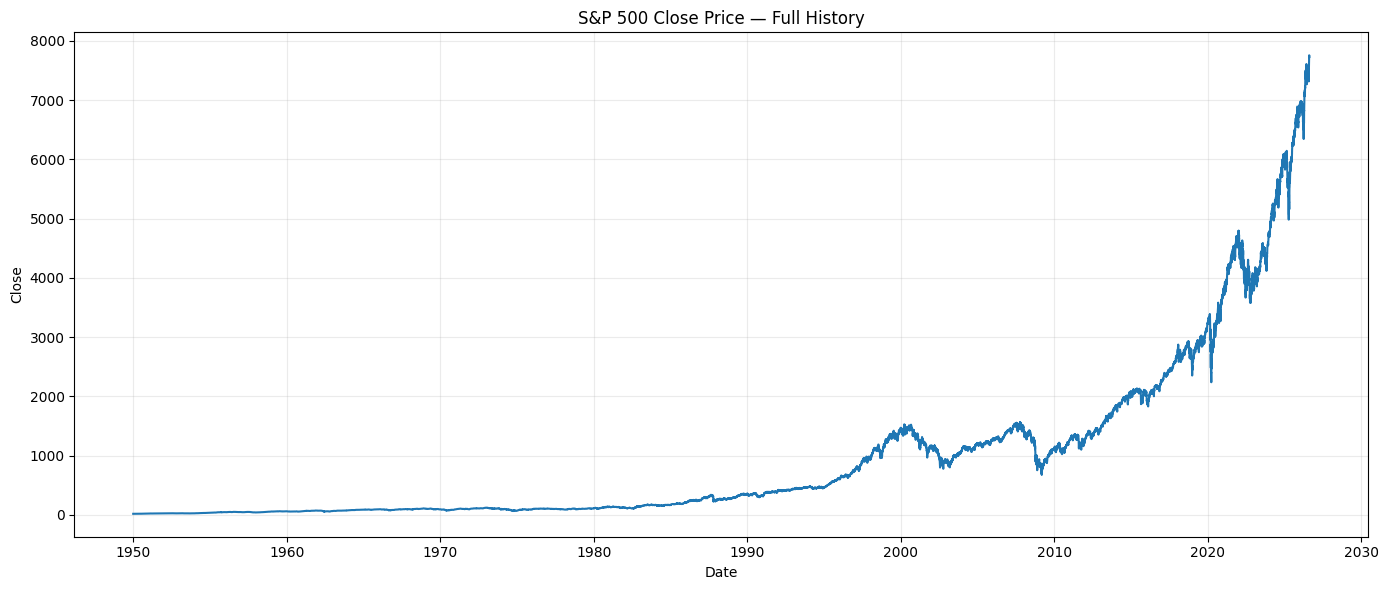

Saved: d:\quant-trading-research\reports\figures\sp500_close_full_history.png


In [23]:
fig = plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title("S&P 500 Close Price — Full History")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_close_full_history.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 7. Log-Scale Long-Run Price View

A logarithmic y-axis helps distinguish percentage-scale growth across very different historical price levels.


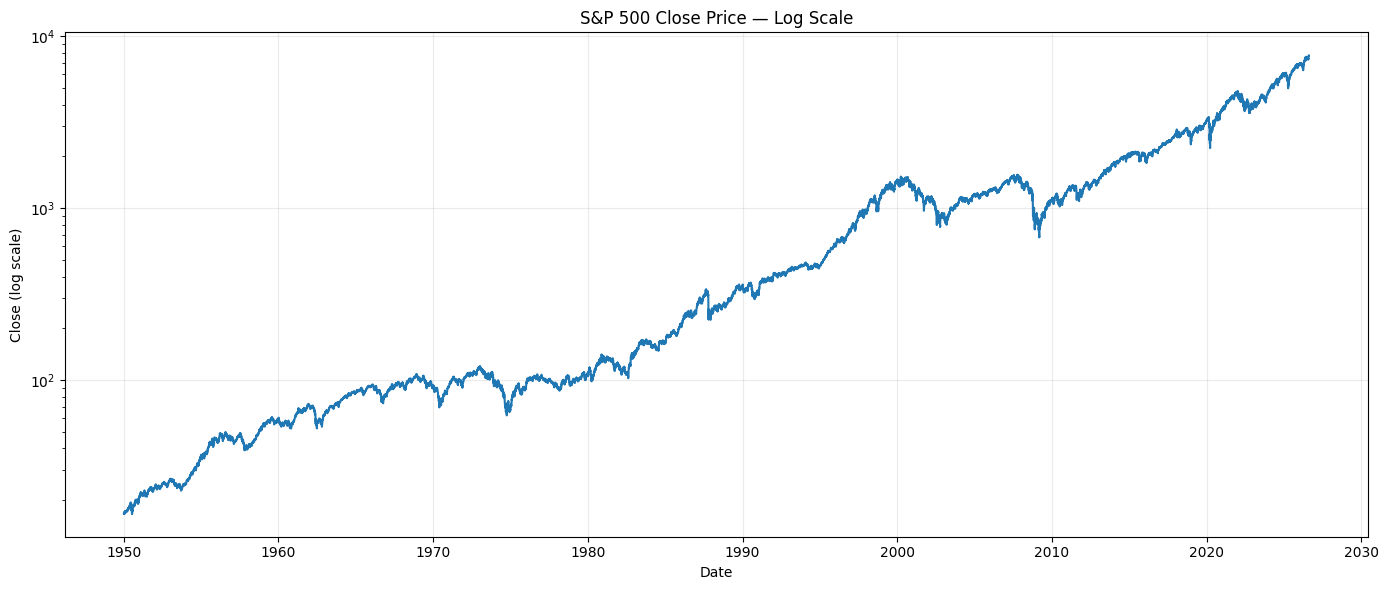

Saved: d:\quant-trading-research\reports\figures\sp500_close_log_scale.png


In [24]:
fig = plt.figure(figsize=(14, 6))
plt.semilogy(df["Date"], df["Close"])
plt.title("S&P 500 Close Price — Log Scale")
plt.xlabel("Date")
plt.ylabel("Close (log scale)")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_close_log_scale.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 8. Trading Volume

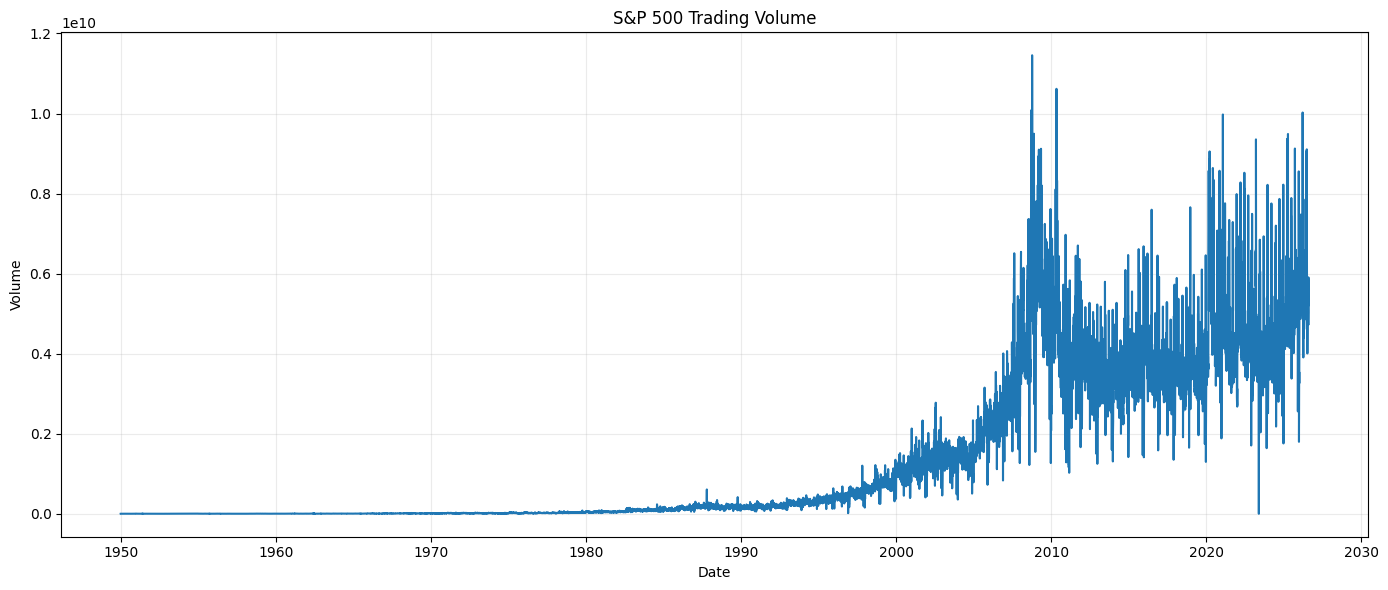

Saved: d:\quant-trading-research\reports\figures\sp500_volume_history.png


In [25]:
fig = plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Volume"])
plt.title("S&P 500 Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_volume_history.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 9. Daily Return Distribution

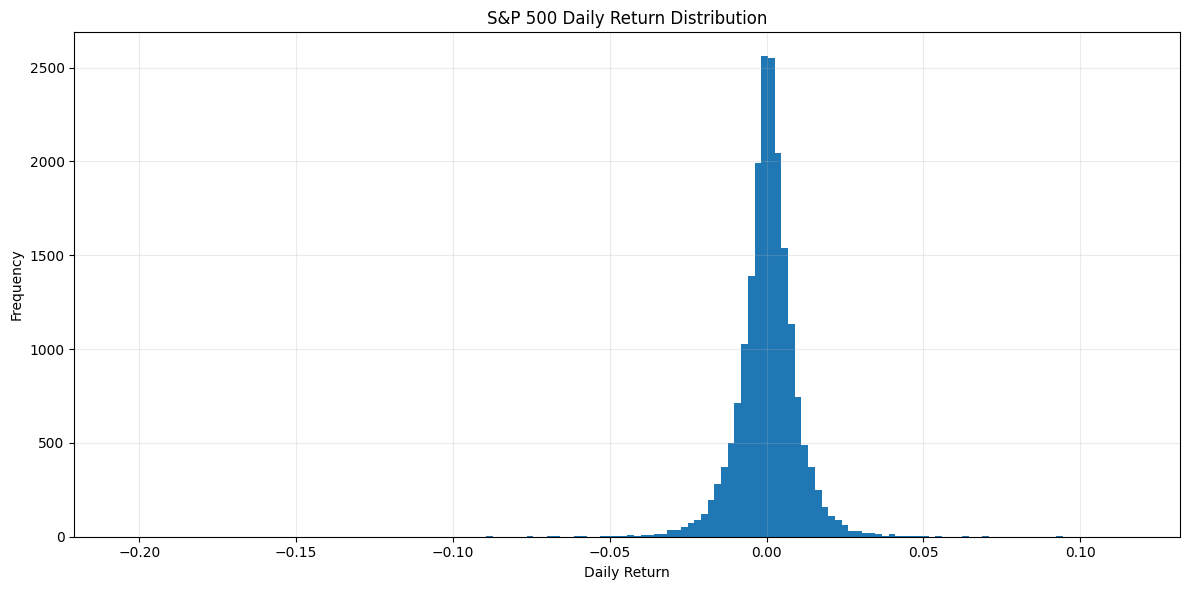

Saved: d:\quant-trading-research\reports\figures\sp500_daily_return_distribution.png


In [26]:
returns = df["daily_return"].dropna()

fig = plt.figure(figsize=(12, 6))
plt.hist(returns, bins=150)
plt.title("S&P 500 Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_daily_return_distribution.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 10. Log Return Distribution

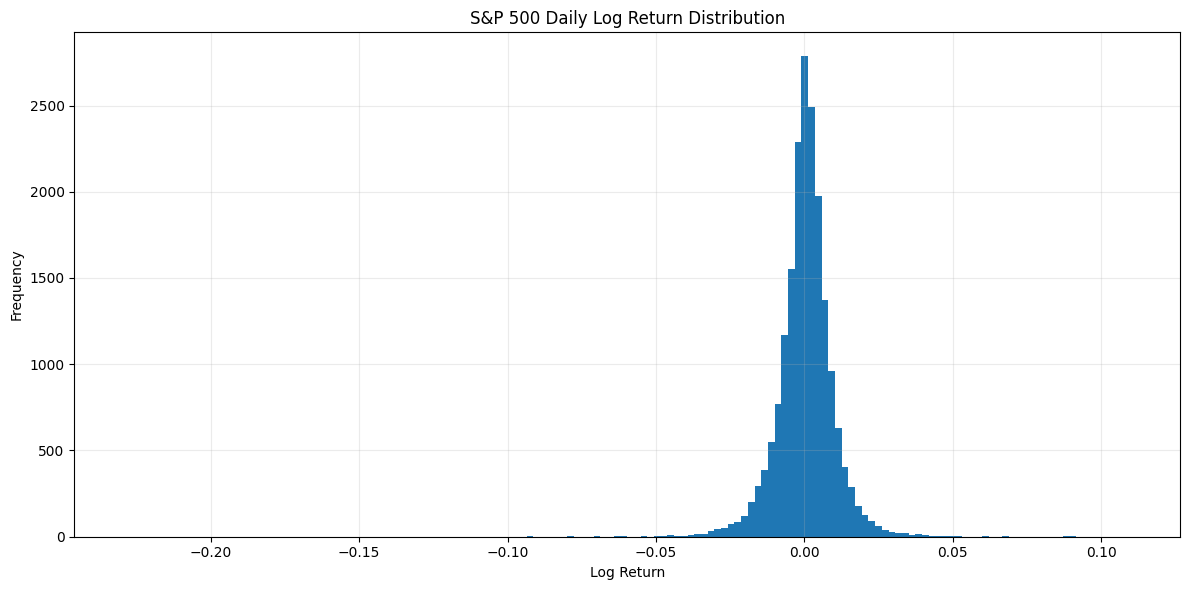

Saved: d:\quant-trading-research\reports\figures\sp500_log_return_distribution.png


In [27]:
log_returns = df["log_return"].dropna()

fig = plt.figure(figsize=(12, 6))
plt.hist(log_returns, bins=150)
plt.title("S&P 500 Daily Log Return Distribution")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_log_return_distribution.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 11. Rolling Volatility

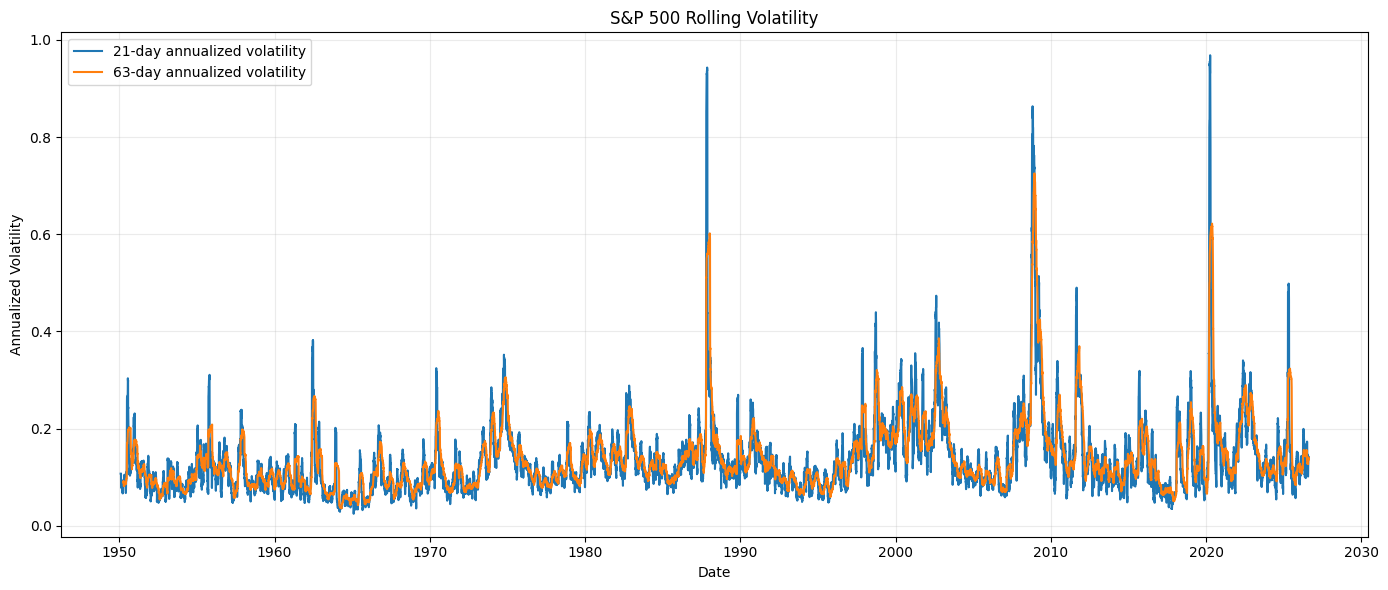

Saved: d:\quant-trading-research\reports\figures\sp500_rolling_volatility.png


In [28]:
fig = plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["volatility_21d"], label="21-day annualized volatility")
plt.plot(df["Date"], df["volatility_63d"], label="63-day annualized volatility")
plt.title("S&P 500 Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_rolling_volatility.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 12. Drawdown Analysis

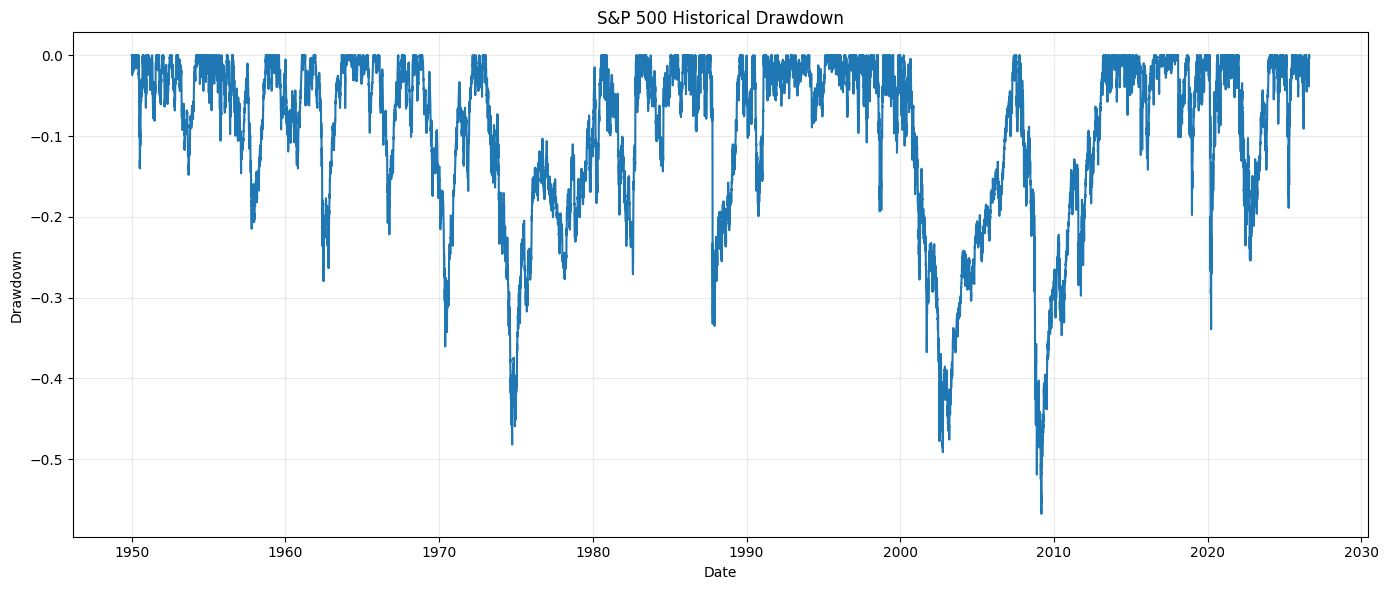

Saved: d:\quant-trading-research\reports\figures\sp500_drawdown_history.png
Maximum observed drawdown: -56.78%
Maximum drawdown date: 2009-03-09


In [29]:
fig = plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["drawdown"])
plt.title("S&P 500 Historical Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_drawdown_history.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")

max_drawdown = df["drawdown"].min()
max_drawdown_date = df.loc[df["drawdown"].idxmin(), "Date"]

print(f"Maximum observed drawdown: {max_drawdown:.2%}")
print(f"Maximum drawdown date: {max_drawdown_date.date()}")


## 13. Moving Average Analysis

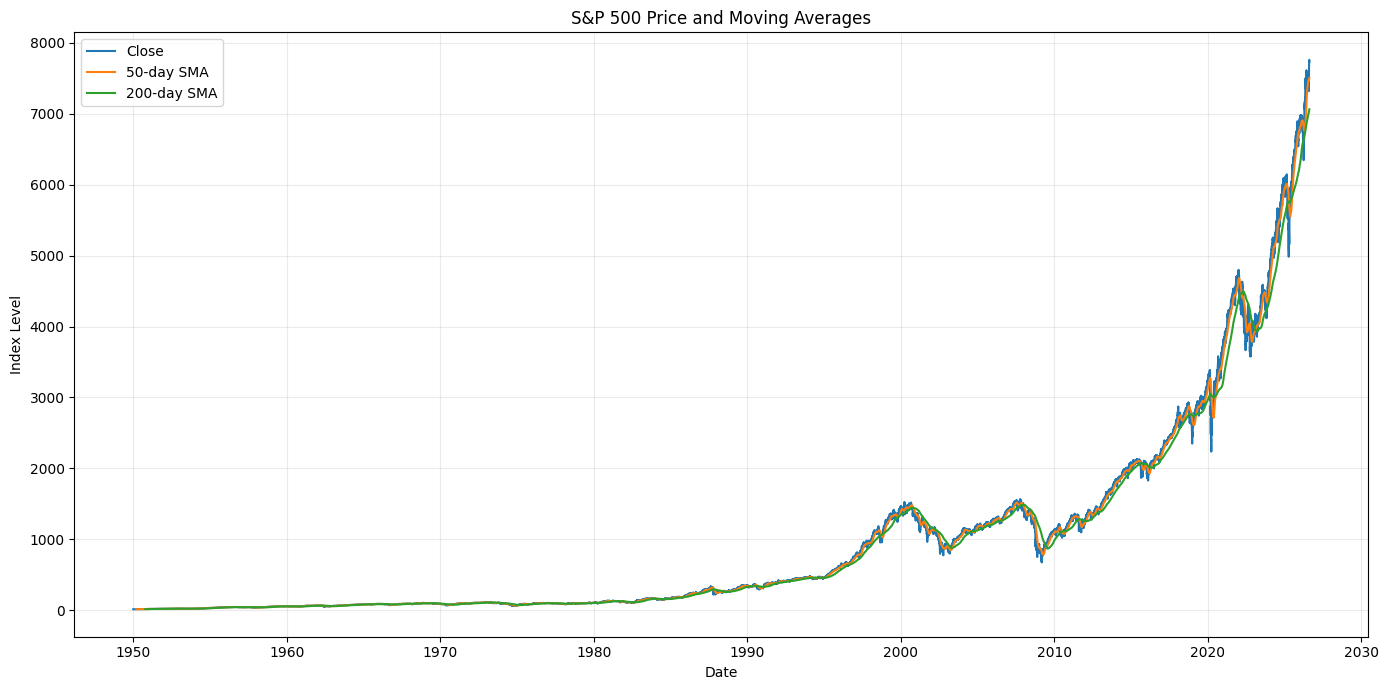

Saved: d:\quant-trading-research\reports\figures\sp500_moving_averages.png


In [30]:
fig = plt.figure(figsize=(14, 7))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["sma_50"], label="50-day SMA")
plt.plot(df["Date"], df["sma_200"], label="200-day SMA")
plt.title("S&P 500 Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_moving_averages.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 14. Daily Trading Range

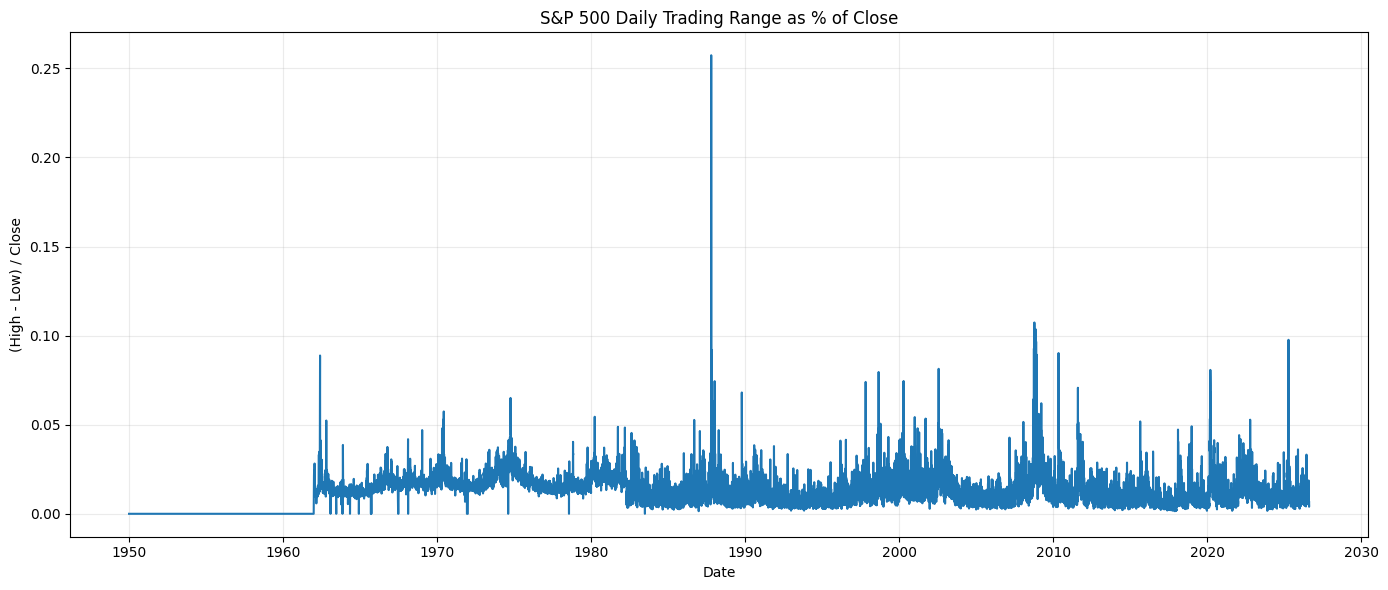

Saved: d:\quant-trading-research\reports\figures\sp500_daily_range_pct.png


In [31]:
fig = plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["range_pct"])
plt.title("S&P 500 Daily Trading Range as % of Close")
plt.xlabel("Date")
plt.ylabel("(High - Low) / Close")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_daily_range_pct.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 15. Intraday vs Overnight Returns

,mean,std,median,min,max
Intraday,0.000241,0.008928,0.0,-0.204669,0.107890
Overnight,0.000124,0.003562,0.0,-0.074669,0.047841


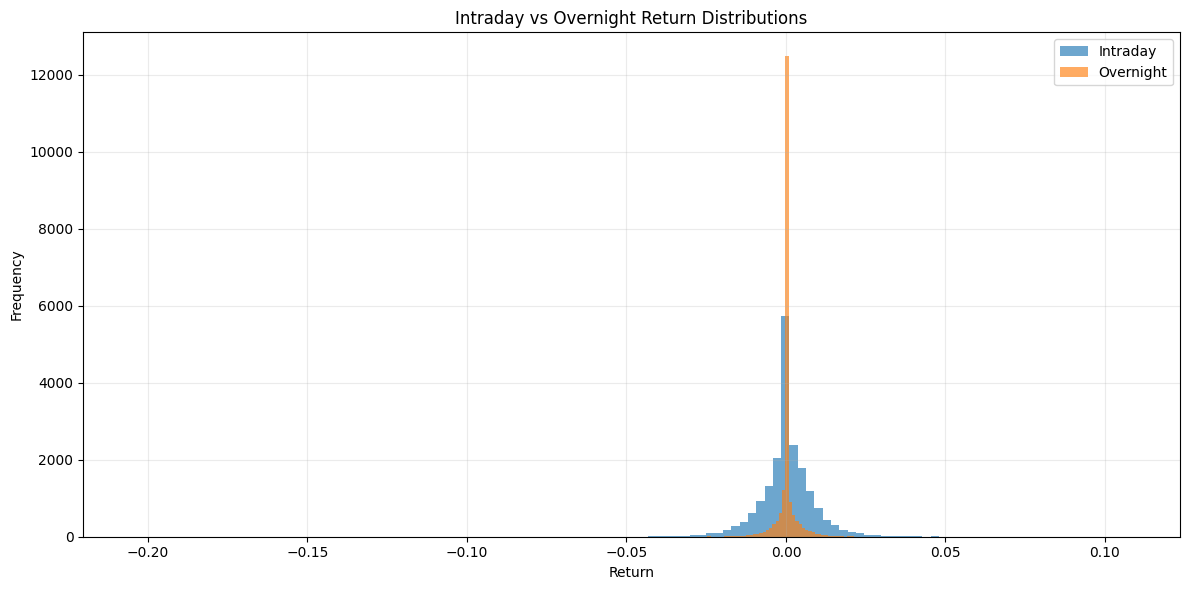

Saved: d:\quant-trading-research\reports\figures\sp500_intraday_vs_overnight.png


In [32]:
comparison = pd.DataFrame({
    "Intraday": df["intraday_return"],
    "Overnight": df["overnight_return"],
}).dropna()

comparison_stats = comparison.agg(
    ["mean", "std", "median", "min", "max"]
).T

display(comparison_stats)

comparison_stats.to_csv(
    TABLE_DIR / "sp500_intraday_overnight_return_stats.csv"
)

fig = plt.figure(figsize=(12, 6))
plt.hist(
    comparison["Intraday"],
    bins=120,
    alpha=0.65,
    label="Intraday"
)
plt.hist(
    comparison["Overnight"],
    bins=120,
    alpha=0.65,
    label="Overnight"
)
plt.title("Intraday vs Overnight Return Distributions")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_intraday_vs_overnight.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 16. Annual Performance Analysis

,annual_return,year
57,0.035296,2007
58,-0.384858,2008
59,0.234542,2009
60,0.127827,2010
61,-0.000032,2011
62,0.134057,2012
63,0.296012,2013
64,0.113906,2014
65,-0.007266,2015
66,0.095350,2016


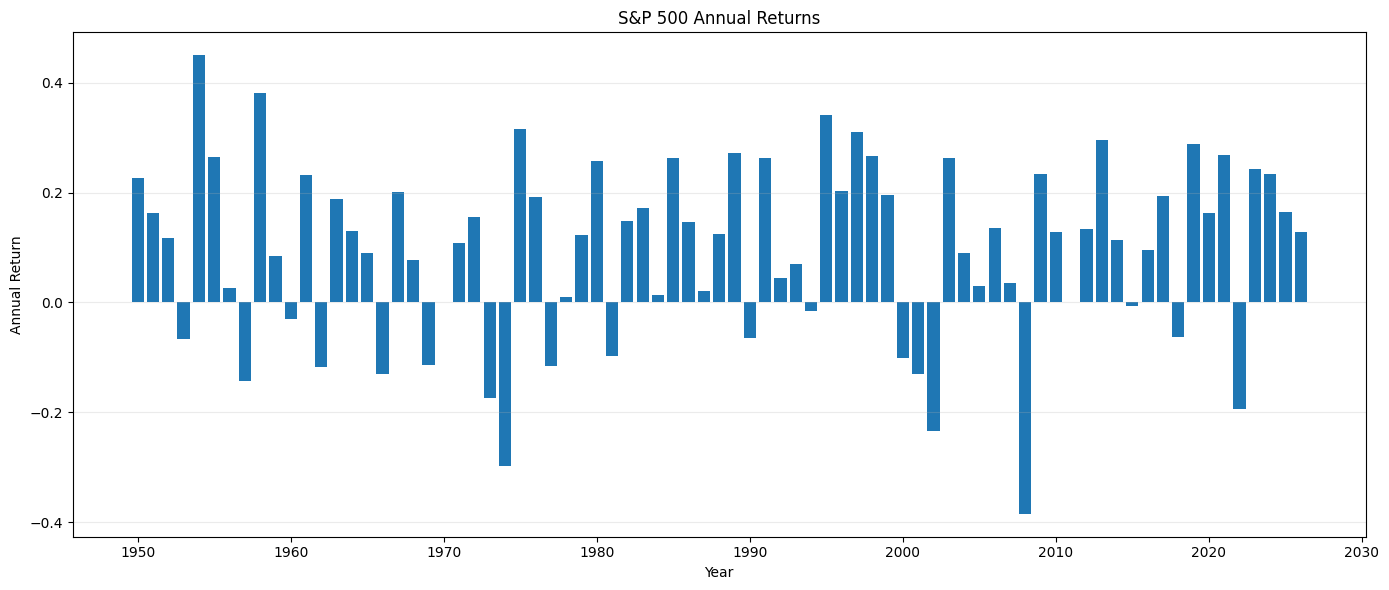

Saved: d:\quant-trading-research\reports\figures\sp500_annual_returns.png


In [33]:
annual = (
    df.set_index("Date")["daily_return"]
    .groupby(pd.Grouper(freq="A"))
    .apply(lambda x: (1 + x.dropna()).prod() - 1)
    .rename("annual_return")
    .to_frame()
)

annual["year"] = annual.index.year
annual = annual.reset_index(drop=True)

display(annual.tail(20))

annual.to_csv(
    TABLE_DIR / "sp500_annual_returns.csv",
    index=False
)

fig = plt.figure(figsize=(14, 6))
plt.bar(annual["year"], annual["annual_return"])
plt.title("S&P 500 Annual Returns")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_annual_returns.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 17. Calendar-Year Volatility

In [ ]:
annual_volatility = (
    df.set_index("Date")["daily_return"]
    .groupby(pd.Grouper(freq="A"))
    .std()
    .mul(np.sqrt(252))
    .rename("annualized_volatility")
    .to_frame()
)

annual_volatility["year"] = annual_volatility.index.year
annual_volatility = annual_volatility.reset_index(drop=True)

display(annual_volatility.tail(20))

annual_volatility.to_csv(
    TABLE_DIR / "sp500_annualized_volatility.csv",
    index=False
)

fig = plt.figure(figsize=(14, 6))
plt.plot(
    annual_volatility["year"],
    annual_volatility["annualized_volatility"]
)
plt.title("S&P 500 Annualized Volatility by Year")
plt.xlabel("Year")
plt.ylabel("Annualized Volatility")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_annualized_volatility.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


ValueError: Invalid frequency: YE

## 18. Historical Regime-Level Summary

The history is divided into broad research eras. These are descriptive groupings only and are not the regime model used later in Notebook 06.


In [ ]:
df["era"] = np.select(
    [
        df["Date"] <= pd.Timestamp("1969-12-31"),
        df["Date"] <= pd.Timestamp("1989-12-31"),
        df["Date"] <= pd.Timestamp("1999-12-31"),
        df["Date"] <= pd.Timestamp("2009-12-31"),
    ],
    [
        "1950-1969",
        "1970-1989",
        "1990-1999",
        "2000-2009",
    ],
    default="2010-present",
)

era_summary = (
    df.groupby("era")
    .agg(
        observations=("Date", "count"),
        mean_daily_return=("daily_return", "mean"),
        daily_return_std=("daily_return", "std"),
        mean_range_pct=("range_pct", "mean"),
        mean_volume=("Volume", "mean"),
        minimum_close=("Close", "min"),
        maximum_close=("Close", "max"),
    )
    .reset_index()
)

era_summary["annualized_return_approx"] = (
    era_summary["mean_daily_return"] * 252
)

era_summary["annualized_volatility"] = (
    era_summary["daily_return_std"] * np.sqrt(252)
)

display(era_summary)

era_summary.to_csv(
    TABLE_DIR / "sp500_era_summary.csv",
    index=False
)


## 19. Return Autocorrelation

In [ ]:
autocorrelation = pd.DataFrame({
    "lag": range(1, 21),
    "autocorrelation": [
        returns.autocorr(lag=i)
        for i in range(1, 21)
    ],
})

display(autocorrelation)

autocorrelation.to_csv(
    TABLE_DIR / "sp500_return_autocorrelation.csv",
    index=False
)

fig = plt.figure(figsize=(12, 6))
plt.bar(
    autocorrelation["lag"],
    autocorrelation["autocorrelation"]
)
plt.title("S&P 500 Daily Return Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_return_autocorrelation.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 20. Squared-Return Autocorrelation

Autocorrelation of squared returns provides a simple exploratory view of volatility clustering.


In [ ]:
squared_returns = returns ** 2

vol_autocorrelation = pd.DataFrame({
    "lag": range(1, 21),
    "autocorrelation": [
        squared_returns.autocorr(lag=i)
        for i in range(1, 21)
    ],
})

display(vol_autocorrelation)

vol_autocorrelation.to_csv(
    TABLE_DIR / "sp500_squared_return_autocorrelation.csv",
    index=False
)

fig = plt.figure(figsize=(12, 6))
plt.bar(
    vol_autocorrelation["lag"],
    vol_autocorrelation["autocorrelation"]
)
plt.title("S&P 500 Squared-Return Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_squared_return_autocorrelation.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 21. Extreme Return Events

In [ ]:
extreme_events = (
    df.loc[
        df["daily_return"].abs() >= 0.05,
        ["Date", "Open", "High", "Low", "Close", "daily_return"]
    ]
    .copy()
)

extreme_events["absolute_return"] = extreme_events["daily_return"].abs()

extreme_events = (
    extreme_events
    .sort_values("absolute_return", ascending=False)
    .drop(columns="absolute_return")
)

display(extreme_events.head(30))

extreme_events.to_csv(
    TABLE_DIR / "sp500_extreme_return_events.csv",
    index=False
)


## 22. Rolling Maximum Drawdown by 252 Trading Days

In [ ]:
rolling_peak = df["Close"].rolling(252, min_periods=20).max()
rolling_drawdown = df["Close"] / rolling_peak - 1

fig = plt.figure(figsize=(14, 6))
plt.plot(df["Date"], rolling_drawdown)
plt.title("Approximate 252-Day Rolling Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_252d_rolling_drawdown.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 23. Correlation of Basic Daily Market Variables

In [ ]:
correlation_columns = [
    "daily_return",
    "log_return",
    "intraday_return",
    "overnight_return",
    "range_pct",
    "volatility_21d",
    "Volume",
]

correlation_matrix = df[correlation_columns].corr()

display(correlation_matrix)

correlation_matrix.to_csv(
    TABLE_DIR / "sp500_basic_variable_correlations.csv"
)


## 24. Exploratory Research Findings Summary

The following metrics summarize observations that will guide the next research notebooks.

No causal conclusions are drawn here.


In [ ]:
findings = {
    "observations": int(len(df)),
    "date_start": df["Date"].min().strftime("%Y-%m-%d"),
    "date_end": df["Date"].max().strftime("%Y-%m-%d"),
    "mean_daily_return": float(returns.mean()),
    "median_daily_return": float(returns.median()),
    "daily_return_std": float(returns.std()),
    "annualized_return_mean_based": float(returns.mean() * 252),
    "annualized_volatility": float(returns.std() * np.sqrt(252)),
    "maximum_drawdown": float(df["drawdown"].min()),
    "maximum_drawdown_date": df.loc[
        df["drawdown"].idxmin(), "Date"
    ].strftime("%Y-%m-%d"),
    "extreme_positive_returns_5pct": int(
        (returns >= 0.05).sum()
    ),
    "extreme_negative_returns_5pct": int(
        (returns <= -0.05).sum()
    ),
    "mean_daily_range_pct": float(df["range_pct"].mean()),
}

findings_path = REPORT_DIR / "sp500_exploratory_findings.json"
findings_path.write_text(
    json.dumps(findings, indent=2),
    encoding="utf-8"
)

print(json.dumps(findings, indent=2))
print(f"\nSaved: {findings_path}")


## 25. Final Integrity Check

The exploratory notebook must not accidentally modify the persisted master CSV.

We reload the CSV and verify its row count and schema against the initial load.


In [ ]:
verification_df = pd.read_csv(MASTER_PATH, low_memory=False)

assert list(verification_df.columns) == EXPECTED_COLUMNS
assert len(verification_df) == len(df)
assert pd.to_datetime(verification_df["Date"], errors="coerce").notna().all()

print("Master CSV integrity after exploratory analysis: PASS")
print(f"Persisted rows: {len(verification_df):,}")
print(f"Persisted columns: {list(verification_df.columns)}")


# Notebook 03 Complete

Notebook 03 has completed exploratory analysis without modifying the master dataset.

### Main outputs

- Long-run price analysis
- Log-scale price analysis
- Volume analysis
- Daily/log-return distributions
- Rolling volatility
- Drawdowns
- Moving averages
- Trading range behavior
- Intraday vs overnight returns
- Annual returns
- Annualized volatility
- Era-level descriptive statistics
- Return autocorrelation
- Squared-return autocorrelation
- Extreme-return event table
- Rolling drawdown
- Correlation matrix
- Exploratory findings JSON

**Next notebook:** Notebook 04 — Return Analysis.

Do not proceed until Notebook 03 has been run and reviewed.
